In [30]:
#Python Data Analysis imports
import pandas as pd
import numpy as np

#Visualisation imports
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

#To grab stock data
import pandas_datareader.data as web
from pandas_datareader.yahoo.headers import DEFAULT_HEADERS
from datetime import datetime as dt
import datetime
import calendar
import yfinance as yf
from sklearn import metrics
from sklearn.linear_model import LinearRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import * 

from tensorflow.keras.callbacks import ModelCheckpoint

from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

# Caching
import requests_cache
import math
from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


#To grab stock data
import pandas_datareader.data as web
from pandas_datareader.yahoo.headers import DEFAULT_HEADERS
from datetime import datetime as dt
import datetime
import calendar
import yfinance as yf
from yahoo_finance import Share

from pandas import read_csv

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV

import plotly.express as px

In [31]:
'''Define all stocks we want to investigate'''
apple_ = "AAPL"
microsoft_ = "MSFT"
disney_ = "DIS"
sas_ = "SAS"
norwegian_ = "NWARF"

# Visualization

In [32]:
def read_stock(stock):
    dframe = yf.download(tickers=stock, start="2012-01-01", end="2023-03-01")
    #df_head = dframe.head()
    return dframe

In [33]:
apple = read_stock("AAPL")
microsoft = read_stock("MSFT")
disney = read_stock("DIS")
norwegian = read_stock("NWARF")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


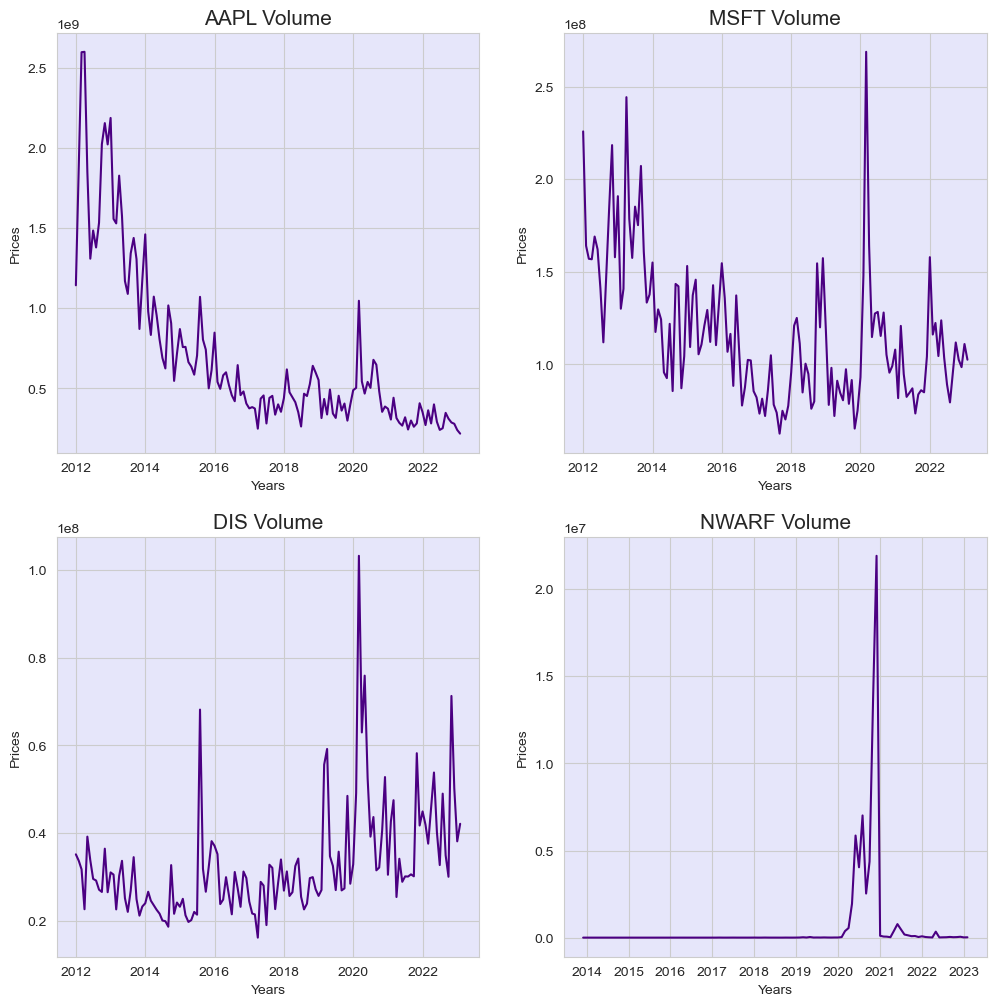

In [34]:
def plot_volume(stocks):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,12))
    ax = ax.flatten()
    for i, stock in enumerate(stocks):
        #Download data from yahoo finance and define start and end date.
        df = yf.download(tickers=stock, start="2012-01-01", end="2023-03-01", interval="1mo")
        #df.drop("Volume", axis=1, inplace=True)
        df["Volume"] = df.mean(axis=1)
        data = pd.Series(df["Volume"])
        data = data.dropna()
        #Plotting the data in each individual subplots
        ax[i].plot(data, c='Indigo')
        ax[i].set_title(f"{stock} Volume", fontsize=15)
        ax[i].set_xlabel("Years")
        ax[i].set_ylabel("Prices")
        ax[i].set_facecolor('lavender')
    plt.show()
    
df_stocks = apple_, microsoft_, disney_, norwegian_
plot_volume(df_stocks)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


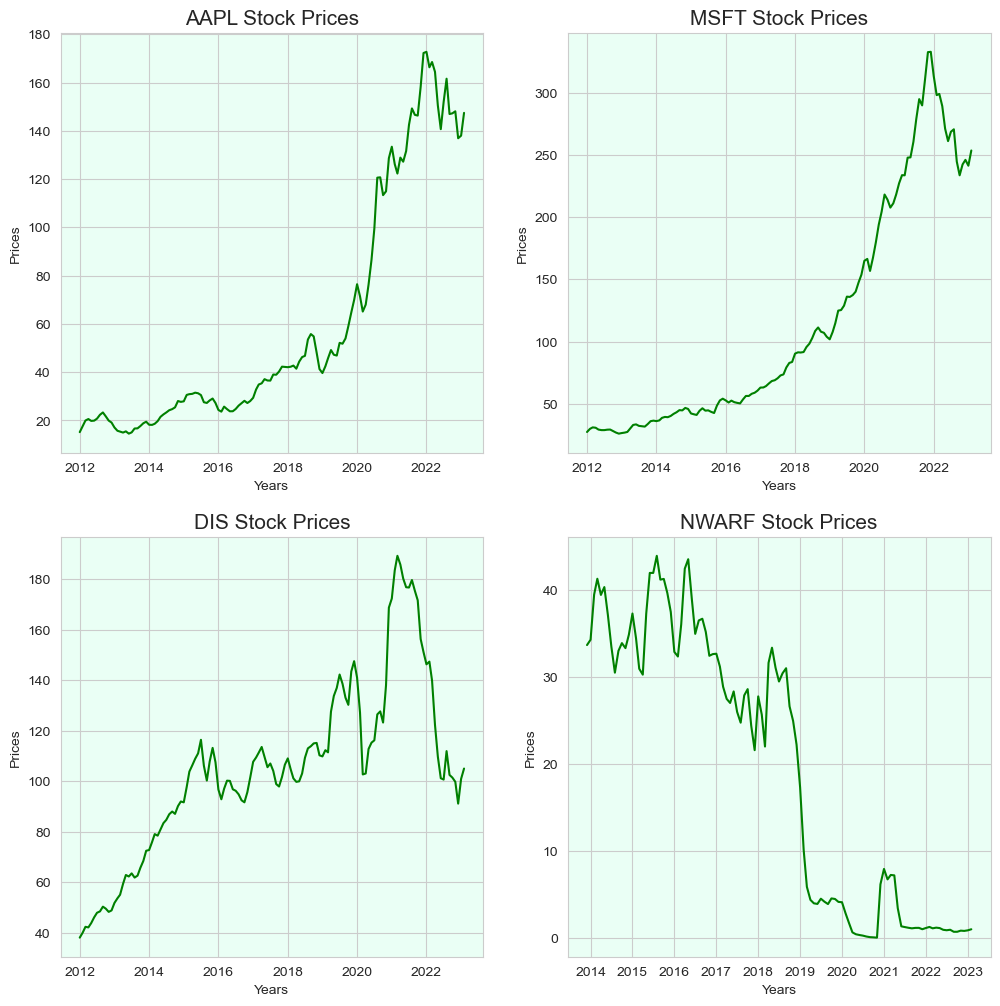

In [35]:
def plot_stocks(stocks):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,12))
    ax = ax.flatten()
    for i, stock in enumerate(stocks):
        #Download data from yahoo finance and define start and end date.
        df = yf.download(tickers=stock, start="2012-01-01", end="2023-03-01", interval="1mo")
        df.drop("Volume", axis=1, inplace=True)
        df["Close"] = df.mean(axis=1)
        data = pd.Series(df["Close"])
        data = data.dropna()
        #Plotting the data in each individual subplots
        ax[i].plot(data, c='green')
        ax[i].set_title(f"{stock} Stock Prices", fontsize=15)
        ax[i].set_xlabel("Years")
        ax[i].set_ylabel("Prices")
        ax[i].set_facecolor('#eafff5')
    plt.show()
plot_stocks(df_stocks)

# QQ-plot

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


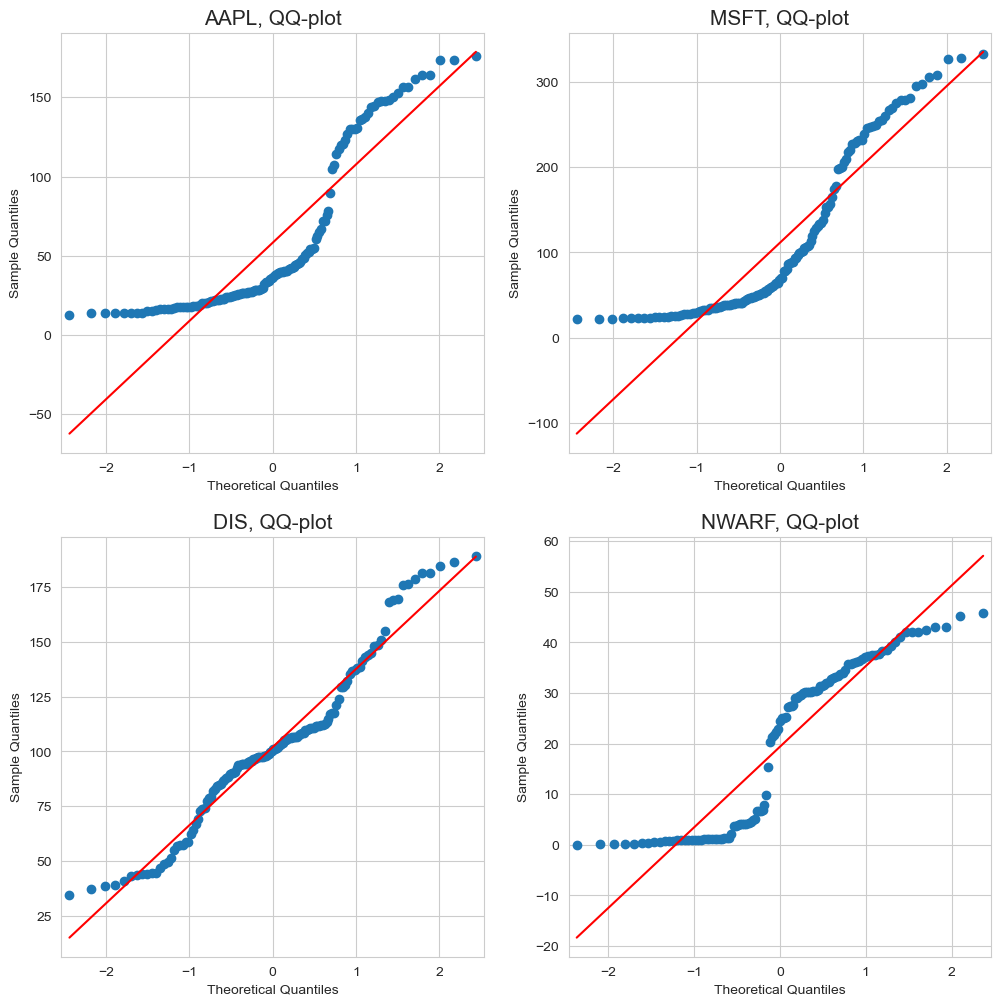

In [36]:
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
def plot_qq_stocks(stocks):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,12))
    ax = ax.flatten()
    for i, stock in enumerate(stocks):
        #Download data from yahoo finance and define start and end date.
        df = yf.download(tickers=stock, start="2012-01-01", end="2023-03-01", interval="1mo")
        ax[i].set_title(f"{stock}, QQ-plot", fontsize=15)
        qqplot(df['Adj Close'], line="s", ax=ax[i])
    plt.show()
plot_qq_stocks(df_stocks)

In [37]:
print('Skewness Apple', apple['Adj Close'].skew())
print('Skewness Norwegian', norwegian['Adj Close'].skew())
print('Skewness Disney', disney['Adj Close'].skew()) 
print('Skewness Microsoft', microsoft['Adj Close'].skew())

Skewness Apple 1.0937120782043952
Skewness Norwegian -0.004937948814366708
Skewness Disney 0.36254117240919764
Skewness Microsoft 0.9063620088994855


# Correlation

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


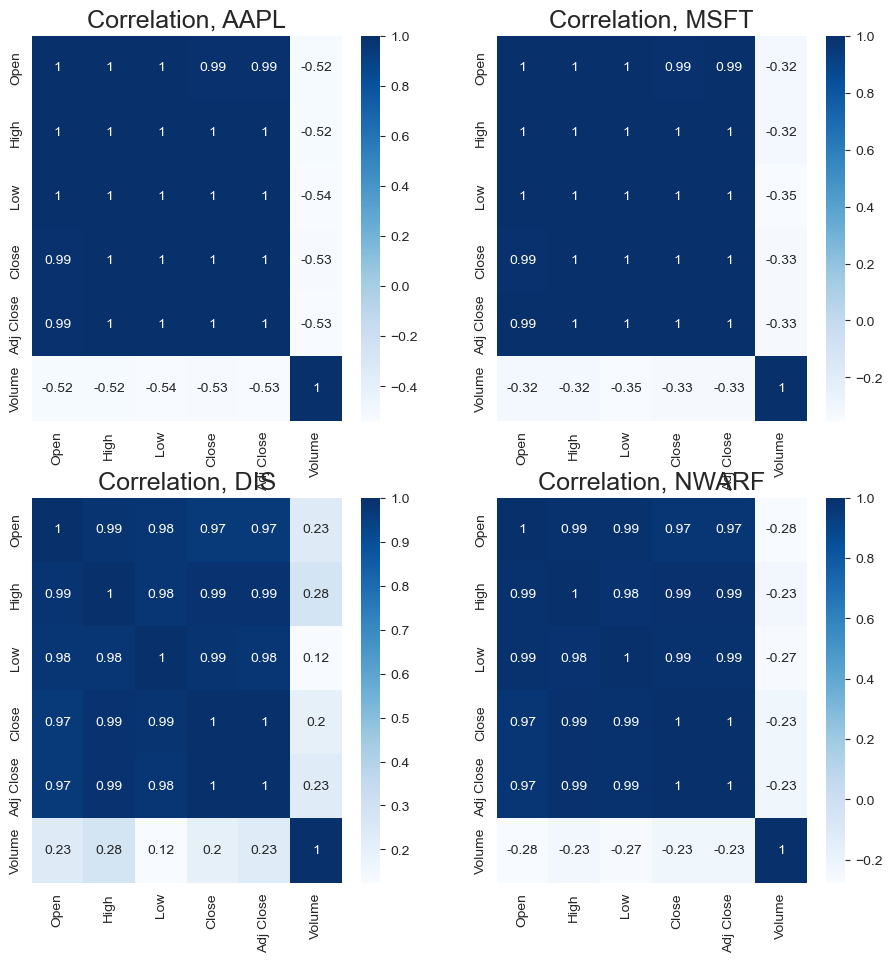

In [38]:
def corr_heatmap(stocks):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(11,11))
    for i, stock in enumerate(stocks):
        df = yf.download(tickers=stock, start="2012-01-01", end="2023-03-01", interval="1mo")
        cormap = df.corr()
        sns.heatmap(cormap, annot = True, cmap='Blues', ax=ax[i//2, i%2])
        ax[i//2, i%2].set_title(f"Correlation, {stock}", fontsize = 18)
    plt.show()
    
corr_heatmap(df_stocks)

In [39]:
#df = yf.download(tickers=apple, start="2012-01-01", end="2023-03-01", interval="1mo")
cormap1 = apple.corr()
cormap2 = norwegian.corr()
cormap3 = disney.corr()
cormap4 = microsoft.corr()
def most_corr_dat(correl_stock, T): 
   #Make to empty columns, one for the features and other for the correlation value
    feature=[]
    abs_corr_val=[]
    for i ,index in enumerate(correl_stock.index):
        #If the absolute value of correlation is greater than a given threshold, then append index to feature
        if abs(correl_stock[index]) > T:
            feature.append(index)
            abs_corr_val.append(correl_stock[index])
    
    df = pd.DataFrame(data = abs_corr_val, index = feature, columns=['Correlation'])
    return df


threshold = 0.7
most_corr = most_corr_dat(cormap1['Close'], threshold), most_corr_dat(cormap2['Close'], threshold)
most_corr2 = most_corr_dat(cormap3['Close'], threshold), most_corr_dat(cormap4['Close'], threshold)
#print(most_corr, most_corr2)
print(most_corr,most_corr2)

(           Correlation
Open          0.999670
High          0.999847
Low           0.999851
Close         1.000000
Adj Close     0.999956,            Correlation
Open          0.999972
High          0.999978
Low           0.999978
Close         1.000000
Adj Close     1.000000) (           Correlation
Open          0.999154
High          0.999584
Low           0.999536
Close         1.000000
Adj Close     0.998390,            Correlation
Open          0.999717
High          0.999857
Low           0.999868
Close         1.000000
Adj Close     0.999959)


In [40]:
#Change start-end interval to evaluate Daily Return
def read_stock(stock):
    dframe = yf.download(tickers=stock, start="2021-01-01", end="2023-03-01")
    return dframe
apple = read_stock("AAPL")
microsoft = read_stock("MSFT")
disney = read_stock("DIS")
norwegian = read_stock("NWARF")
df_stocks2 = apple, microsoft, disney, norwegian

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


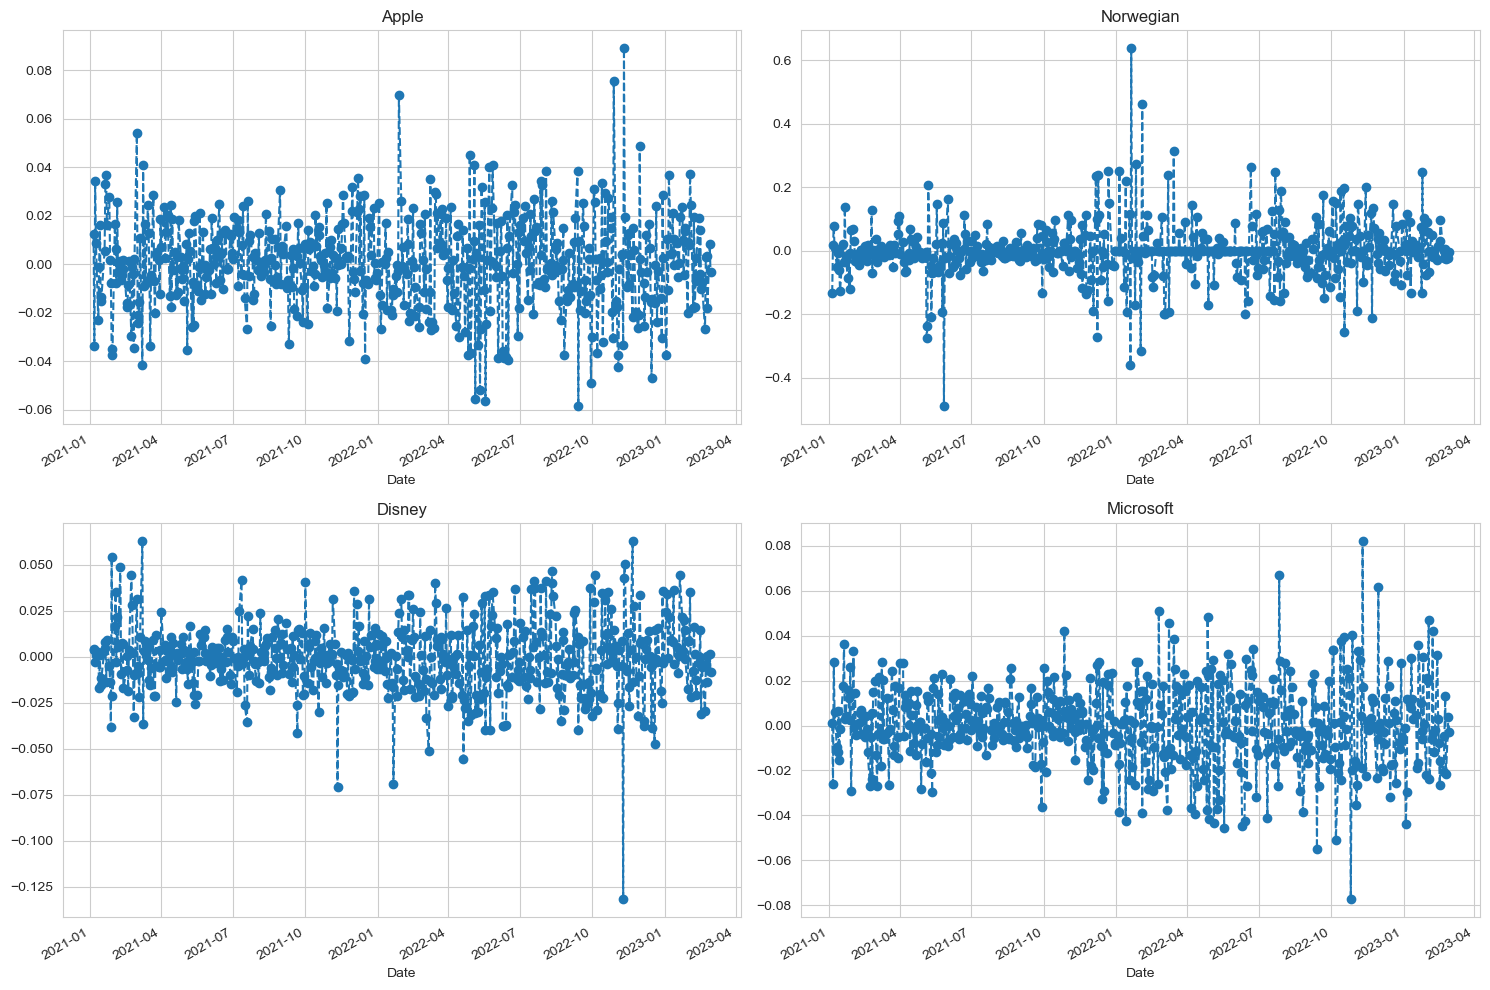

In [41]:
for company in df_stocks2:
    company['Daily Return'] = company['Adj Close'].pct_change()

# Then we'll plot the daily return percentage
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

apple['Daily Return'].plot(ax=axes[0,0], linestyle='--', marker='o')
axes[0,0].set_title('Apple')

norwegian['Daily Return'].plot(ax=axes[0,1], linestyle='--', marker='o')
axes[0,1].set_title('Norwegian')

disney['Daily Return'].plot(ax=axes[1,0], linestyle='--', marker='o')
axes[1,0].set_title('Disney')

microsoft['Daily Return'].plot(ax=axes[1,1], linestyle='--', marker='o')
axes[1,1].set_title('Microsoft')

fig.tight_layout()

# Linear Regression

In [42]:
apple['Date'] = apple.index 
apple

,Open,High,Low,Close,Adj Close,Volume,Daily Return,Date
Date,,,,,,,,
2021-01-04,133.520004,133.610001,126.760002,129.410004,127.680000,143301900,NaN,2021-01-04
2021-01-05,128.889999,131.740005,128.429993,131.009995,129.258636,97664900,0.012364,2021-01-05
2021-01-06,127.720001,131.050003,126.379997,126.599998,124.907570,155088000,-0.033662,2021-01-06
2021-01-07,128.360001,131.630005,127.860001,130.919998,129.169800,109578200,0.034123,2021-01-07
2021-01-08,132.429993,132.630005,130.229996,132.050003,130.284714,105158200,0.008631,2021-01-08
...,...,...,...,...,...,...,...,...
2023-02-22,148.869995,149.949997,147.160004,148.910004,148.910004,51011300,0.002896,2023-02-22
2023-02-23,150.089996,150.339996,147.240005,149.399994,149.399994,48394200,0.003291,2023-02-23
2023-02-24,147.110001,147.190002,145.720001,146.710007,146.710007,55469600,-0.018005,2023-02-24


In [43]:

def read_stock(stock):
    dframe = yf.download(tickers=stock, start="2012-01-01", end="2023-03-01")
    #df_head = dframe.head()
    return dframe
apple = read_stock("AAPL")
microsoft = read_stock("MSFT")
disney = read_stock("DIS")
norwegian = read_stock("NWARF")
df_stocks2 = apple, microsoft, disney, norwegian

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [44]:
df_Stock = apple

#df_Stock = apple, microsoft, disney, norwegian

def train_test_split(Stock):
    train = df_Stock.drop(columns=['Adj Close'], axis=1)
    test = df_Stock['Adj Close'] #Target
    data_len = df_Stock.shape[0]
    #Split the train
    split_tr = int(data_len * 0.9)
    split_vals = split_tr + int(data_len * 0.1)
    # Splitting features and target into train, validation and test samples 
    X_train, X_test = train[:split_tr], train[split_vals:]
    Y_train, Y_test = test[:split_tr],test[split_vals:]
    #Validation
    X_valid, Y_valid = train[split_tr:split_vals], test[split_tr:split_vals]
    return X_train, X_valid, X_test, Y_train, Y_valid, Y_test

X_train, X_valid, X_test, Y_train, Y_valid, Y_test = train_test_split(df_stocks)

LR Coefficients: [-5.98003269e-02  1.14239449e-01 -8.49968780e-03  9.59625013e-01
 -1.02972353e-09]
r2 scoore: 0.9998927167808481


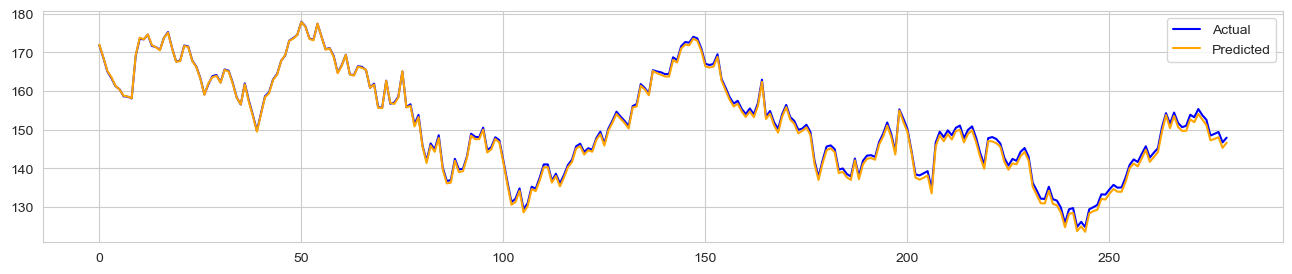

In [45]:
#Make dataframe of actual vs predicted values
def act_vs_pred(stock):
    lr = LinearRegression()
    lr.fit(X_train, Y_train)
    
    print('LR Coefficients:', lr.coef_)
    print('r2 score:', lr.score(X_train, Y_train))
    
    Y_train_pred = lr.predict(X_train)
    Y_val_pred = lr.predict(X_valid)
    Y_test_pred = lr.predict(X_test)
    df_pred = pd.DataFrame(Y_valid.values, columns=['Actual'], index=Y_valid.index)
    df_pred['Predicted'] = Y_val_pred
    df_pred = df_pred.reset_index()
    #print(df_pred.head())
    plt.figure(figsize=(16,3))
    range_of_dates = df_pred.index
    plt.plot(range_of_dates, df_pred['Actual'], c = 'Blue', label = 'Actual')
    plt.plot(range_of_dates, df_pred['Predicted'], c = 'Orange', label = 'Predicted')
    plt.legend()
    plt.show()
    #return df_pred


act_vs_pred(df_Stock)

# ARIMA Model

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2327
Model:                 ARIMA(4, 1, 0)   Log Likelihood               -2801.615
Date:                Wed, 26 Apr 2023   AIC                           5613.230
Time:                        12:05:15   BIC                           5641.989
Sample:                             0   HQIC                          5623.709
                               - 2327                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0019      0.022     -0.091      0.928      -0.044       0.040
ar.L2          0.0073      0.016      0.443      0.657      -0.025       0.039
ar.L3          0.0008      0.023      0.037      0.9

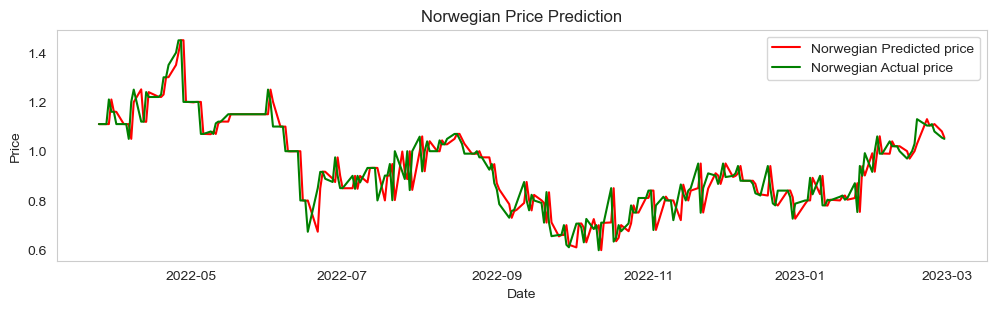

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2806
Model:                 ARIMA(4, 1, 0)   Log Likelihood               -5151.459
Date:                Wed, 26 Apr 2023   AIC                          10312.918
Time:                        12:05:54   BIC                          10342.614
Sample:                             0   HQIC                         10323.636
                               - 2806                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0564      0.009     -5.986      0.000      -0.075      -0.038
ar.L2         -0.0276      0.010     -2.878      0.004      -0.046      -0.009
ar.L3         -0.0280      0.010     -2.689      0.0

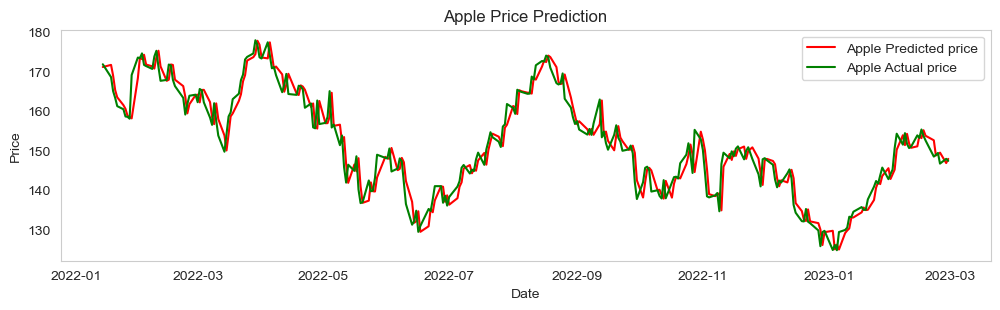

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2806
Model:                 ARIMA(4, 1, 0)   Log Likelihood               -6724.980
Date:                Wed, 26 Apr 2023   AIC                          13459.961
Time:                        12:06:46   BIC                          13489.656
Sample:                             0   HQIC                         13470.679
                               - 2806                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1123      0.009    -12.582      0.000      -0.130      -0.095
ar.L2         -0.0190      0.009     -2.086      0.037      -0.037      -0.001
ar.L3         -0.0375      0.010     -3.771      0.0

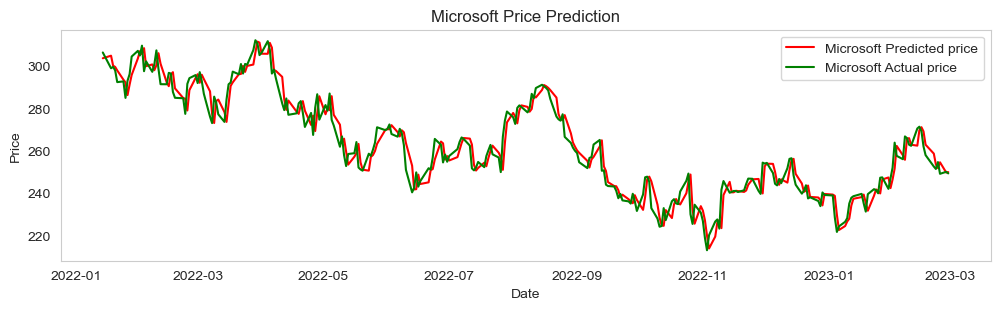

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2806
Model:                 ARIMA(4, 1, 0)   Log Likelihood               -5714.806
Date:                Wed, 26 Apr 2023   AIC                          11439.612
Time:                        12:07:31   BIC                          11469.308
Sample:                             0   HQIC                         11450.330
                               - 2806                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0518      0.010     -5.079      0.000      -0.072      -0.032
ar.L2          0.0063      0.011      0.581      0.561      -0.015       0.028
ar.L3          0.0028      0.012      0.244      0.8

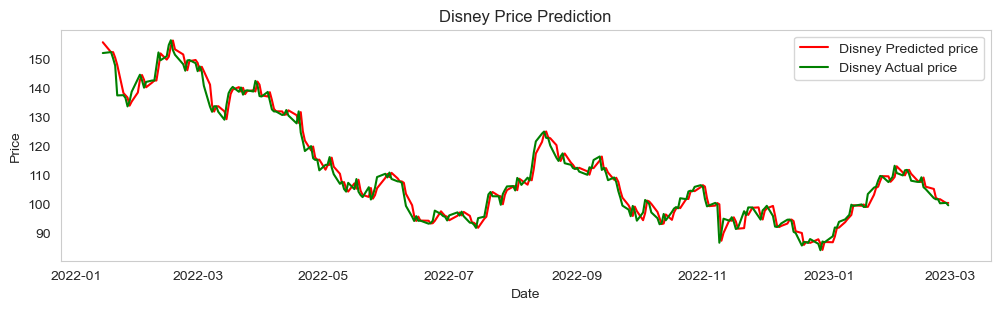

In [46]:
from statsmodels.tsa.arima.model import ARIMA

def ARIMA_predictor(stock_data,train_size,stock_name='Apple',p=4,q=1, d=0):
    df=stock_data
    size = int(len(df)*train_size)
    train = list(df[0:size]['Adj Close'].dropna())
    test = list(df[size:]['Adj Close'].dropna())

    #plt.figure(figsize=(16,3))
    #plt.plot(df[0:size]['Adj Close'],'red',label='train data')
    #plt.plot(df[size:]['Adj Close'],'blue',label='test data')
    #plt.legend()
    #plt.show()

    predictions = []
    n = len(test)

    for i in range(n):
        model = ARIMA(train, order=(p, q, d))
        model_fit = model.fit()
        result = model_fit.forecast()
        y_pred = result[0]
        predictions.append(y_pred)
        real_test_value = test[i]
        train.append(real_test_value)

    print(model_fit.summary())
    
    
    
    range_of_dates = df[size:].index
    plt.figure(figsize=(12,3))
    plt.plot(range_of_dates,predictions,color='red', label= stock_name + ' ' + 'Predicted price')
    plt.plot(range_of_dates,test,color='green', label= stock_name + ' ' + 'Actual price')
    plt.title(stock_name + ' ' + 'Price Prediction')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.grid()
    plt.legend()
    plt.show()
    
ARIMA_predictor(stock_data=norwegian,train_size=0.9,p=4,q=1,d=0,stock_name='Norwegian')
ARIMA_predictor(stock_data=apple,train_size=0.9,p=4,q=1,d=0,stock_name='Apple')
ARIMA_predictor(stock_data=microsoft,train_size=0.9,p=4,q=1,d=0,stock_name='Microsoft')
ARIMA_predictor(stock_data=disney,train_size=0.9,p=4,q=1,d=0,stock_name='Disney')

# Random Forest

In [47]:
def read_stock(stock):
    data = yf.download(stock, start="2020-01-01", end="2023-03-01")
    df=pd.DataFrame(data)
    df.to_csv(stock+".csv")
    data = pd.read_csv(stock+".csv")
    return(data)

In [48]:
apple = read_stock("AAPL")
norwegian = read_stock("NWARF")
microsoft = read_stock("MSFT")
disney = read_stock("DIS")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [49]:
def Adj_close(data,Adj=False):
    data.set_index("Date", inplace=True)
    if Adj == True:
        data=data['Adj Close']
        return (data)
    else: 
        return(data)

In [50]:
apple=Adj_close(apple,Adj=True)
norwegian=Adj_close(norwegian,Adj=True)
microsoft=Adj_close(microsoft,Adj=True)
disney=Adj_close(disney,Adj=True)

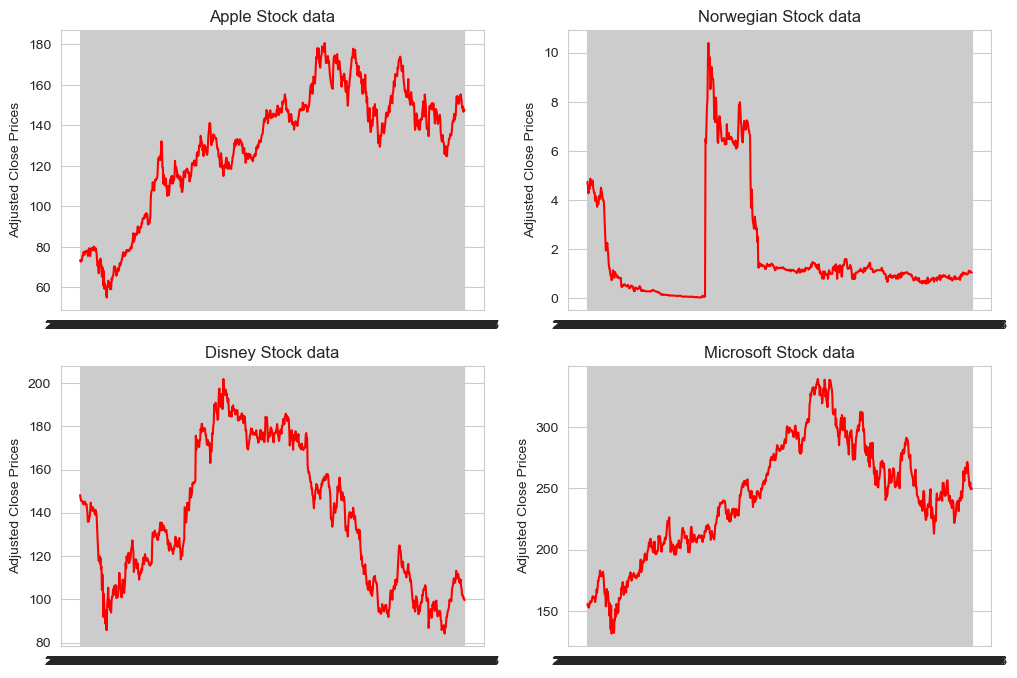

In [51]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
ax1.plot(apple.index, apple,color='red')
ax1.set_title('Apple Stock data')
ax1.set_ylabel("Adjusted Close Prices")


ax2.plot(norwegian.index, norwegian,color='red')
ax2.set_title('Norwegian Stock data')
ax2.set_ylabel("Adjusted Close Prices")


ax3.plot(disney.index, disney,color='red')
ax3.set_title('Disney Stock data')
ax3.set_ylabel("Adjusted Close Prices")


ax4.plot(microsoft.index, microsoft,color='red')
ax4.set_title('Microsoft Stock data')
ax4.set_ylabel("Adjusted Close Prices")


plt.show()

In [52]:
apple = read_stock("AAPL")
norwegian = read_stock("NWARF")
microsoft = read_stock("MSFT")
disney = read_stock("DIS")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [53]:
apple=Adj_close(apple)
norwegian=Adj_close(norwegian)
microsoft=Adj_close(microsoft)
disney=Adj_close(disney)

In [54]:
from sklearn.model_selection import train_test_split
def DataTransformation(data):
    # Drop any rows with missing values
    data.dropna(inplace=True)

    # Create a new column for the target variable
    data['Adj_Close_Future'] = data['Adj Close'].shift(-1)

    # Drop the last row, which contains NaN for the target variable
    data.drop(data.tail(1).index, inplace=True)

    # Create a new column for the percent change in the Adj Close price
    data['Adj_Close_pct_change'] = (data['Adj Close'] - data['Adj Close'].shift(1)) / data['Adj Close'].shift(1)

    # Create a new column for the 50-day moving average
    data['50MA'] = data['Adj Close'].rolling(window=50).mean()

    # Create a new column for the 200-day moving average
    data['200MA'] = data['Adj Close'].rolling(window=200).mean()

    # Drop any rows with missing values
    data.dropna(inplace=True)

    # Set the features and target variables
    X = data[['Open', 'High', 'Low', 'Close', 'Volume', 'Adj_Close_pct_change', '50MA', '200MA']]
    y = data['Adj_Close_Future']

    # Standardize the features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Split the data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)




    # Perform feature selection using Randomized Search CV
    model = RandomForestRegressor()
    param_distributions = {
        'n_estimators': [100, 500, 1000],
        'max_features': ['sqrt', 'log2'],
        'max_depth': [10, 20, 30, 40, 50, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }
   
    rs = RandomizedSearchCV(model, param_distributions, n_iter=10, cv=3, n_jobs=-1, random_state=0)
    rs.fit(x_train, y_train)

    # Print the best parameters found by Randomized Search CV
    print(rs.best_params_)
    rf_reg = RandomForestRegressor()
    # Create a randomized search object to find the best hyperparameters
    rf_reg_random = RandomizedSearchCV(estimator=rf_reg, param_distributions=param_distributions, n_iter=10, cv=5, verbose=2, random_state=42, n_jobs=-1)
    #rf_reg_random = RandomizedSearchCV(estimator=rf_reg, param_distributions=param_distributions, n_iter=n_iter, cv=cv, verbose=verbose, random_state=random_state, n_jobs=n_jobs)
    # Fit the randomized search object to the training data
    rf_reg_random.fit(x_train, y_train)

    # Get the best hyperparameters and create a new random forest regressor object
    best_params = rf_reg_random.best_params_
    rf_reg = RandomForestRegressor(**best_params)

    # Fit the random forest regressor to the training data
    rf_reg.fit(x_train, y_train)

    # Use the random forest regressor to predict the test data
    y_pred = rf_reg.predict(x_test)

    print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
    print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
    print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
    print('R^2 Score:', metrics.r2_score(y_test, y_pred))
    print('Train Score:', rf_reg.score(x_train, y_train))
    print('Test Score:', rf_reg.score(x_test, y_test))
    return y_pred, y_test



In [55]:
apple_predict=DataTransformation(data=apple)
disney_predict=DataTransformation(data=disney)
norwegian_predict=DataTransformation(data=norwegian)
microsoft_predict=DataTransformation(data=microsoft)

{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': False}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mean Absolute Error: 2.3119084972573054
Mean Squared Error: 8.417923721276336
Root Mean Squared Error: 2.9013658372008755
R^2 Score: 0.9700722795684267
Train Score: 0.9844322183585964
Test Score: 0.9700722795684267
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mean Absolute Error: 1.9451241433985125
Mean Squared Error: 6.875568224278311
Root Mean Squared Error: 2.6221304743048752
R^2 Score: 0.9937454712687438
Train Score: 0.9979166345205055
Test Score: 0.9937454712687438
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 f

In [67]:
def plotFunction(apple_y_pred,apple_y_test,norwegian_y_pred,norwegian_y_test,disney_y_pred,disney_y_test,microsoft_y_pred,microsoft_y_test):
    df1 = pd.DataFrame({'Actual': apple_y_test, 'Predicted': apple_y_pred}, index=apple_y_test.index)
    df2 = pd.DataFrame({'Actual': norwegian_y_test, 'Predicted': norwegian_y_pred}, index=norwegian_y_test.index)
    df3 = pd.DataFrame({'Actual': disney_y_test, 'Predicted': disney_y_pred}, index=disney_y_test.index)
    df4 = pd.DataFrame({'Actual': microsoft_y_test, 'Predicted': microsoft_y_pred}, index=microsoft_y_test.index)

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
    plt.figure(figsize=(15,5))
    ax1.plot(df1.index, df1['Actual'], label='Actual')
    ax1.plot(df1.index, df1['Predicted'], label='Predicted')
    ax1.set_title('Apple Random Forest Regressor - Actual vs. Predicted')
    ax1.set_xlabel('Date')
    ax1.legend()


    ax2.plot(df2.index, df2['Actual'], label='Actual')
    ax2.plot(df2.index, df2['Predicted'], label='Predicted')
    ax2.set_title('Norwegian Random Forest Regressor - Actual vs. Predicted')
    ax2.set_xlabel('Date')
    ax2.legend()


    ax3.plot(df3.index, df3['Actual'], label='Actual')
    ax3.plot(df3.index, df3['Predicted'], label='Predicted')
    ax3.set_title('Disney Random Forest Regressor - Actual vs. Predicted')
    ax3.set_xlabel('Date')
    ax3.legend()


    ax4.plot(df4.index, df4['Actual'], label='Actual')
    ax4.plot(df4.index, df4['Predicted'], label='Predicted')
    ax4.set_title('Microsoft Random Forest Regressor - Actual vs. Predicted')
    ax4.set_xlabel('Date')
    ax4.legend()


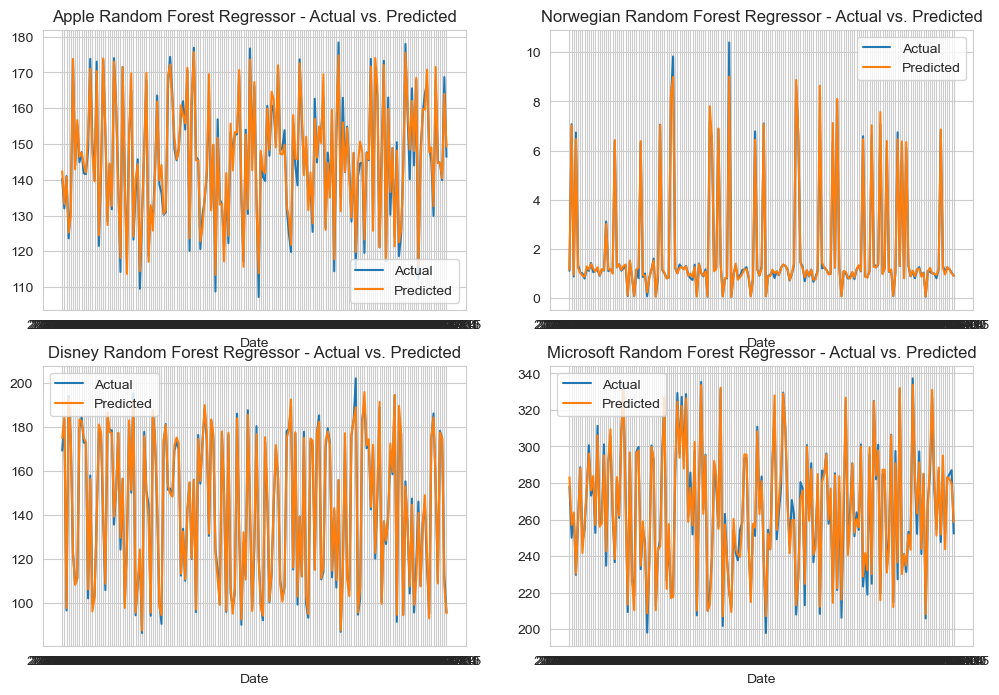

<Figure size 1500x500 with 0 Axes>

In [68]:
plotFunction(apple_predict[0],apple_predict[1],norwegian_predict[0],
             norwegian_predict[1],disney_predict[0],disney_predict[1],microsoft_predict[0],microsoft_predict[1])  

# LSTM Model

In [58]:
apple = read_stock("AAPL")
norwegian = read_stock("NWARF")
microsoft = read_stock("MSFT")
disney=read_stock("DIS")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [59]:
def df_to_x_y(df, window_size=5):
    df_as_np = df.to_numpy()
    X = []
    y = []
    for i in range(len(df_as_np)-window_size):
        row = [[a]for a in df_as_np[i:i+window_size]]
        X.append(row)
        label = df_as_np[i+window_size]
        y.append(label)
    return np.array(X), np.array(y)

In [60]:
X,y=df_to_x_y(norwegian_adj_close)
X_train,y_train = X[:1650],y[:1650]
X_val,y_val =X[1650:1900],y[1650:1900]
X_test,y_test =X[1900:2284],y[1900:2284]
X_train.shape

NameError: name 'norwegian_adj_close' is not defined

In [ ]:
model = Sequential()

#make input layer
model.add(InputLayer((5,1)))
model.add(LSTM(64))
model.add(Dense(8, 'relu'))

#make output layer
model.add(Dense(1, 'linear'))

model.summary()

In [ ]:
model.compile(loss=MeanSquaredError(),optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model.fit(X_train, y_train, validation_data=(X_val,y_val), epochs=10, batch_size=20)

In [ ]:
test_predictions=model.predict(X_test).flatten()
test_results = pd.DataFrame(data={'Model Predictions': test_predictions, 'Actuals': y_test})
test_results

In [ ]:
plt.plot(test_results['Model Predictions'])
plt.plot(test_results['Actuals'])

In [ ]:
model2= Sequential()
model2.add(LSTM(64, activation='relu',input_shape=(X_train.shape[1],X_train.shape[2]), return_sequences=True))
model2.add(LSTM(32, activation='relu', return_sequences=False))
model2.add(Dropout(0.2))
model2.add(Dense(1))
model2.compile(optimizer='adam',loss='mse')
model2.summary

In [ ]:
model2.fit(X_train, y_train, validation_split=0.1, epochs=10, batch_size=16)
test_results = pd.DataFrame({'Model Predictions': model2.predict(X_test).flatten(), 'Actuals': y_test.flatten()})
print(test_results)
test_results.plot(figsize=(10, 5))
plt.show()

In [ ]:
microsoft_adj_close=microsoft['Adj Close']
apple_adj_close=apple['Adj Close']
disney_adj_close=disney['Adj Close']

In [ ]:
def predict_stock_prices(stock, window_size=5, train_size=1650, lstm=64,val_size=250, test_size=334, epochs=10,lr=0.0001, batch_size=20):
    """
    Takes in a pandas dataframe of historical stock prices and returns a trained LSTM model for predicting
    future stock prices based on the last `window_size` number of historical prices. It also plots the model's
    predicted prices and the actual prices for the test set.
    """
    
    
    X,y = df_to_x_y(stock)
    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
    X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]
    
    model1 = Sequential()
    
    # make input layer
    model1.add(InputLayer((window_size, 1)))
    model1.add(LSTM(lstm))
    model1.add(Dense(8, 'relu'))
    
    # make output layer
    model1.add(Dense(1, 'linear'))
    
    model1.summary()
    model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=lr), metrics=[RootMeanSquaredError()])
    model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size)
    
    test_results = pd.DataFrame({'Model Predictions': model1.predict(X_test).flatten(), 'Actuals': y_test.flatten()})
    print(test_results)
    test_results.plot(figsize=(10, 5))
    plt.xlabel('Index')
    plt.ylabel('Amount')
    plt.grid()
    plt.show()
    
    return model1


In [ ]:
def predict_stock_prices2(stock, window_size=5, train_size=1650, lstm=64, test_size=334, epochs=10,lr=0.0001,validation_split=0.1, batch_size=16):
    X,y = df_to_x_y(stock)
    X_train, y_train = X[:train_size], y[:train_size]
    X_test, y_test = X[train_size:], y[train_size:]

    model2= Sequential()
    model2.add(LSTM(64, activation='relu',input_shape=(X_train.shape[1],X_train.shape[2]), return_sequences=True))
    model2.add(LSTM(32, activation='relu', return_sequences=False))
    model2.add(Dropout(0.2))
    model2.add(Dense(1))
    model2.compile(optimizer='adam',loss='mse')
    model2.summary
    model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size,validation_split=validation_split)

    test_results = pd.DataFrame({'Model Predictions': model2.predict(X_test).flatten(), 'Actuals': y_test.flatten()})
    print(test_results)
    test_results.plot(figsize=(10, 5))
    plt.xlabel('Index')
    plt.ylabel('Amount')
    plt.grid()
    plt.show()
    return model2

In [ ]:
predict_stock_prices(stock=norwegian_adj_close,epochs=10,lstm=64, batch_size=10,lr=.001)

In [ ]:
predict_stock_prices2(stock=norwegian_adj_close, window_size=5, train_size=1650, 
                      lstm=64, test_size=334, epochs=10,lr=0.0001,validation_split=0.1, batch_size=16)


In [ ]:
predict_stock_prices(stock=microsoft_adj_close,epochs=9,lstm=128, batch_size=4,lr=.01)

In [ ]:
predict_stock_prices2(stock=microsoft_adj_close, window_size=5, train_size=1650, lstm=6, 
                      test_size=334, epochs=10,lr=0.0001,validation_split=0.1, batch_size=16)


In [ ]:
predict_stock_prices(stock=apple_adj_close,epochs=10,lstm=128, batch_size=10,lr=.01)

In [ ]:
predict_stock_prices2(stock=apple_adj_close, window_size=5, train_size=1650, lstm=64,
                      test_size=334, epochs=10,lr=0.0001,validation_split=0.1, batch_size=16)


In [ ]:
predict_stock_prices(stock=disney_adj_close,epochs=10,lstm=128, batch_size=10,lr=.01)


In [ ]:
predict_stock_prices2(stock=disney_adj_close, window_size=5, train_size=1650, lstm=64,
                      test_size=334, epochs=10,lr=0.0001,validation_split=0.1, batch_size=16)
